<a href="https://colab.research.google.com/github/shreyasri9/diabetic_learning_model/blob/main/diabetics_data_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

DATA EXPLORATION

In [49]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [50]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [51]:
diabetic = pd.read_csv("/content/drive/MyDrive/diabetics.csv")

In [52]:
print(diabetic.head())

   a  b   c   d   e   f   g   h          I          j          k         l  \
0  1  1  22  22  22  19  18  14  49.895756  17.775994   5.270920  0.771761   
1  1  1  24  24  22  18  16  13  57.709936  23.799994   3.325423  0.234185   
2  1  1  62  60  59  54  47  33  55.831441  27.993933  12.687485  4.852282   
3  1  1  55  53  53  50  43  31  40.467228  18.445954   9.118901  3.079428   
4  1  1  44  44  44  41  39  27  18.026254   8.570709   0.410381  0.000000   

          m         n         o         p         q         r  s  outcome  
0  0.018632  0.006864  0.003923  0.003923  0.486903  0.100025  1        0  
1  0.003903  0.003903  0.003903  0.003903  0.520908  0.144414  0        0  
2  1.393889  0.373252  0.041817  0.007744  0.530904  0.128548  0        1  
3  0.840261  0.272434  0.007653  0.001531  0.483284  0.114790  0        0  
4  0.000000  0.000000  0.000000  0.000000  0.475935  0.123572  0        1  


In [53]:
print(diabetic.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1151 entries, 0 to 1150
Data columns (total 20 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   a        1151 non-null   int64  
 1   b        1151 non-null   int64  
 2   c        1151 non-null   int64  
 3   d        1151 non-null   int64  
 4   e        1151 non-null   int64  
 5   f        1151 non-null   int64  
 6   g        1151 non-null   int64  
 7   h        1151 non-null   int64  
 8   I        1151 non-null   float64
 9   j        1151 non-null   float64
 10  k        1151 non-null   float64
 11  l        1151 non-null   float64
 12  m        1151 non-null   float64
 13  n        1151 non-null   float64
 14  o        1151 non-null   float64
 15  p        1151 non-null   float64
 16  q        1151 non-null   float64
 17  r        1151 non-null   float64
 18  s        1151 non-null   int64  
 19  outcome  1151 non-null   int64  
dtypes: float64(10), int64(10)
memory usage: 180.0 KB
Non

In [54]:
print(diabetic.describe())

                 a            b            c            d            e  \
count  1151.000000  1151.000000  1151.000000  1151.000000  1151.000000   
mean      0.996525     0.918332    38.428323    36.909644    35.140747   
std       0.058874     0.273977    25.620913    24.105612    22.805400   
min       0.000000     0.000000     1.000000     1.000000     1.000000   
25%       1.000000     1.000000    16.000000    16.000000    15.000000   
50%       1.000000     1.000000    35.000000    35.000000    32.000000   
75%       1.000000     1.000000    55.000000    53.000000    51.000000   
max       1.000000     1.000000   151.000000   132.000000   120.000000   

                 f            g            h            I            j  \
count  1151.000000  1151.000000  1151.000000  1151.000000  1151.000000   
mean     32.297133    28.747176    21.151173    64.096674    23.088012   
std      21.114767    19.509227    15.101560    58.485289    21.602696   
min       1.000000     1.000000     1

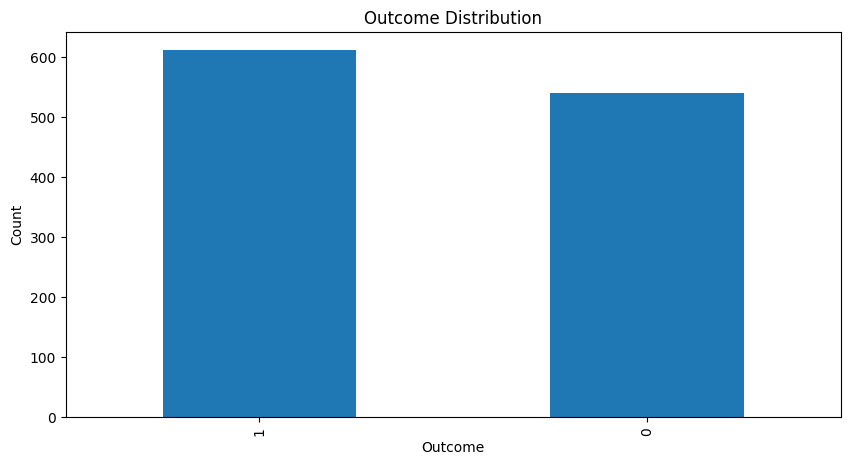

In [55]:
plt.figure(figsize=(10,5))

diabetic['outcome'].value_counts().head(20).plot(kind='bar')

plt.title("Outcome Distribution")
plt.xlabel("Outcome")
plt.ylabel("Count")

plt.show()

In [56]:
diabetic['outcome'].value_counts()

,count
outcome,
1,611
0,540


In [57]:
diabetic.isnull().sum()

,0
a,0
b,0
c,0
d,0
e,0
f,0
g,0
h,0
I,0
j,0


In [58]:
X = diabetic.drop("outcome", axis=1)
y = diabetic["outcome"]

FINDING OUT THE CORRELATION BETWEEN FEATURES

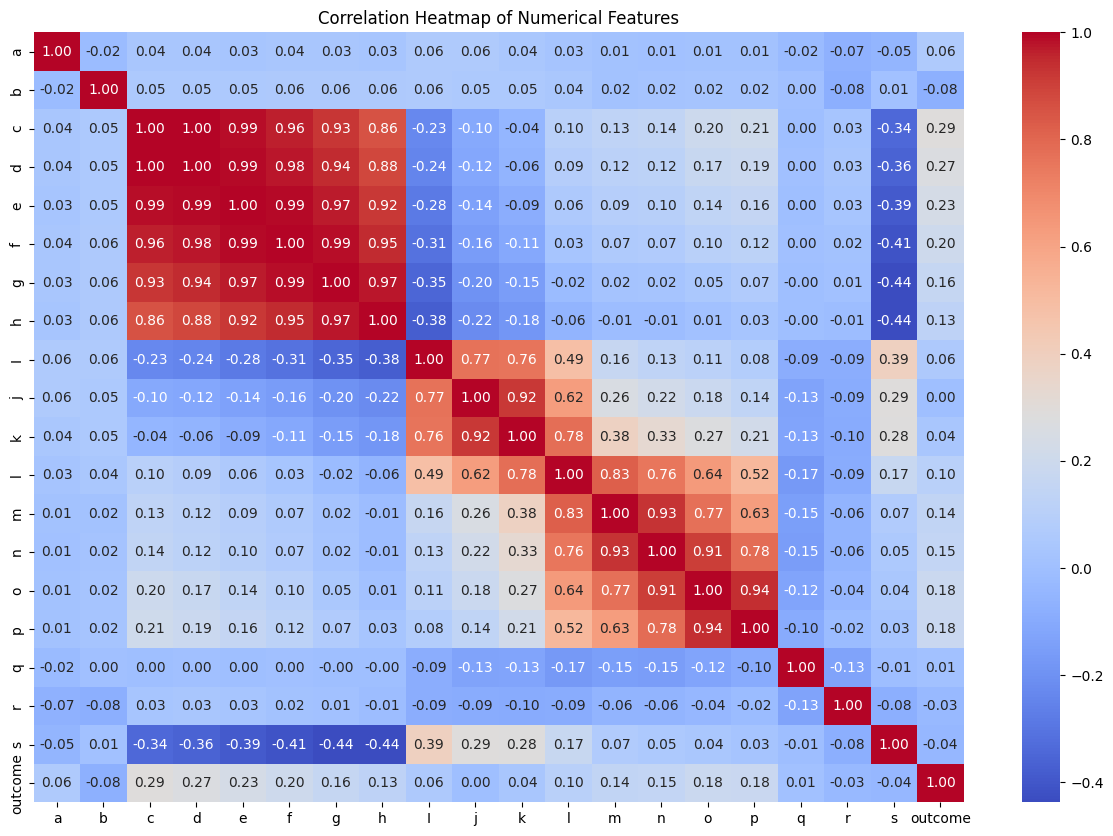

In [59]:
#correlation formula for finding out top related features
correlation_matrix = diabetic.corr(numeric_only=True)
plt.figure(figsize=(15, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

In [60]:
outcome_correlations = correlation_matrix['outcome'].abs().sort_values(ascending=False)
#no relation with outcome
top_5_correlated_features = outcome_correlations[1:6]

print("Top 5 features most strongly correlated with 'outcome':")
print(top_5_correlated_features)

Top 5 features most strongly correlated with 'outcome':
c    0.292603
d    0.266338
e    0.234691
f    0.197511
o    0.184772
Name: outcome, dtype: float64


5 FEATURES WITTH EACH OTHER

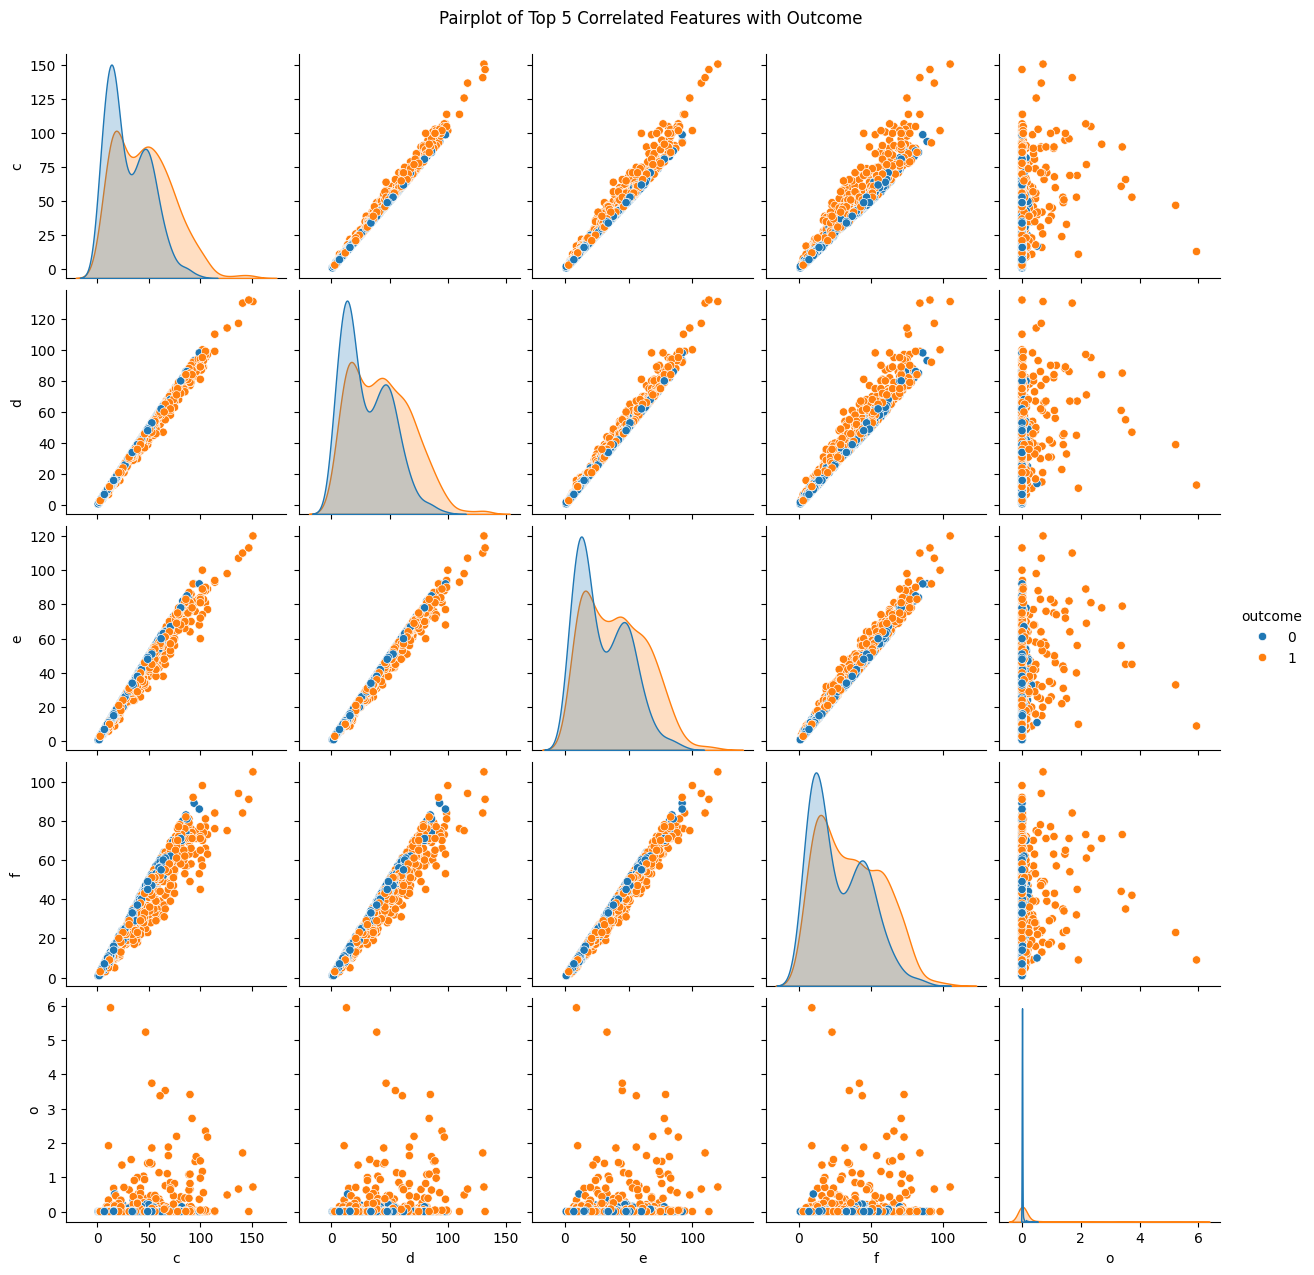

In [61]:
selected_features = top_5_correlated_features.index.tolist() + ['outcome']

sns.pairplot(diabetic[selected_features], hue='outcome', diag_kind='kde')
plt.suptitle('Pairplot of Top 5 Correlated Features with Outcome', y=1.02)
plt.show()

# DATA PREPARATION (TOP 5 FEATURES)

We are filtering the dataset to include only the top 5 features most strongly correlated with the outcome and splitting the data into training and testing sets.

In [99]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Filter to top 5 features
selected_features = top_5_correlated_features.index.tolist()
X = diabetic[selected_features]
y = diabetic['outcome']

# Split into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scaling the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Selected Features: {selected_features}")
print(f"Training set shape: {X_train_scaled.shape}")
print(f"Testing set shape: {X_test_scaled.shape}")
display(X_train.head())

Selected Features: ['c', 'd', 'e', 'f', 'o']
Training set shape: (920, 5)
Testing set shape: (231, 5)


,c,d,e,f,o
1139,12,12,10,9,0.000000
880,90,79,77,72,0.050338
97,24,24,22,22,0.000000
849,64,62,60,57,0.035195
723,16,15,13,12,0.004003


LOGISTIC REGRESSION

Logistic Regression Accuracy: 0.7316

Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.86      0.75       108
           1       0.84      0.62      0.71       123

    accuracy                           0.73       231
   macro avg       0.75      0.74      0.73       231
weighted avg       0.76      0.73      0.73       231



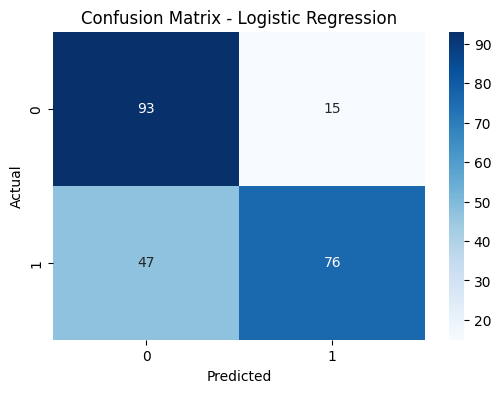

In [100]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Initialize and train the model
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train_scaled, y_train)

# Make predictions
y_pred_log_reg = log_reg.predict(X_test_scaled)

# Evaluate the model
accuracy_log_reg = accuracy_score(y_test, y_pred_log_reg)
print(f"Logistic Regression Accuracy: {accuracy_log_reg:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_log_reg))

# Display Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_log_reg), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

Hyperparameter Tuning

In [101]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga']
}

# Initialize GridSearchCV
grid_log_reg = GridSearchCV(LogisticRegression(random_state=42, max_iter=5000), param_grid, cv=5, scoring='accuracy', n_jobs=-1)

# Fit the grid search
grid_log_reg.fit(X_train_scaled, y_train)

# Get the best model
best_log_reg = grid_log_reg.best_estimator_

# Evaluate the tuned model
y_pred_tuned_log_reg = best_log_reg.predict(X_test_scaled)
accuracy_tuned_log_reg = accuracy_score(y_test, y_pred_tuned_log_reg)

print(f"Best Parameters: {grid_log_reg.best_params_}")
print(f"Tuned Logistic Regression Accuracy: {accuracy_tuned_log_reg:.4f}")
print("\nClassification Report (Tuned Model):")
print(classification_report(y_test, y_pred_tuned_log_reg))

Best Parameters: {'C': 100, 'penalty': 'l1', 'solver': 'liblinear'}
Tuned Logistic Regression Accuracy: 0.7403

Classification Report (Tuned Model):
              precision    recall  f1-score   support

           0       0.68      0.82      0.75       108
           1       0.81      0.67      0.73       123

    accuracy                           0.74       231
   macro avg       0.75      0.75      0.74       231
weighted avg       0.75      0.74      0.74       231



COMPARISION

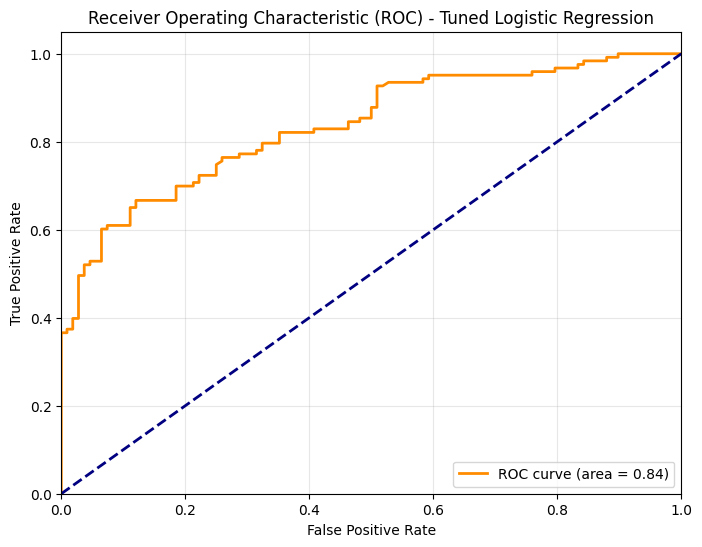

ROC AUC Score: 0.8369


In [102]:
from sklearn.metrics import roc_curve, roc_auc_score

# Get predicted probabilities for the positive class
y_pred_proba_tuned = best_log_reg.predict_proba(X_test_scaled)[:, 1]

# Calculate ROC curve data
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_tuned)
roc_auc = roc_auc_score(y_test, y_pred_proba_tuned)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) - Tuned Logistic Regression')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

print(f"ROC AUC Score: {roc_auc:.4f}")

Random Forest Classifier



Random Forest Accuracy: 0.7229

Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.77      0.72       108
           1       0.77      0.68      0.72       123

    accuracy                           0.72       231
   macro avg       0.73      0.73      0.72       231
weighted avg       0.73      0.72      0.72       231



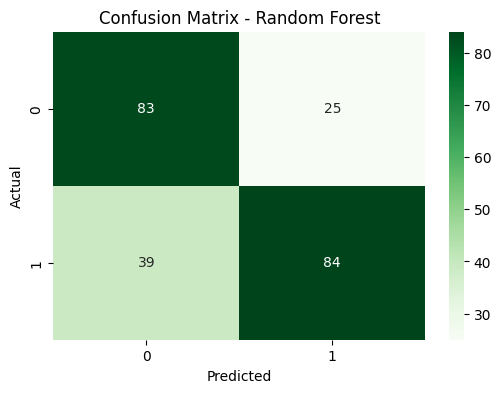

In [103]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize the Random Forest model
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
rf_clf.fit(X_train_scaled, y_train)

# Make predictions
y_pred_rf = rf_clf.predict(X_test_scaled)

# Evaluate performance
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {accuracy_rf:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

# Plot Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

Hyperparameter Tuning


In [104]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for Random Forest
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_leaf': [1, 5, 10]
}

# Initialize GridSearchCV
grid_rf = GridSearchCV(RandomForestClassifier(random_state=42), param_grid_rf, cv=5, scoring='accuracy', n_jobs=-1)

# Fit the grid search
grid_rf.fit(X_train_scaled, y_train)

# Get the best model
best_rf = grid_rf.best_estimator_

# Evaluate the tuned model
y_pred_tuned_rf = best_rf.predict(X_test_scaled)
accuracy_tuned_rf = accuracy_score(y_test, y_pred_tuned_rf)

print(f"Best Parameters: {grid_rf.best_params_}")
print(f"Tuned Random Forest Accuracy: {accuracy_tuned_rf:.4f}")
print("\nClassification Report (Tuned Model):")
print(classification_report(y_test, y_pred_tuned_rf))

Best Parameters: {'max_depth': None, 'min_samples_leaf': 5, 'n_estimators': 200}
Tuned Random Forest Accuracy: 0.7489

Classification Report (Tuned Model):
              precision    recall  f1-score   support

           0       0.70      0.81      0.75       108
           1       0.80      0.70      0.75       123

    accuracy                           0.75       231
   macro avg       0.75      0.75      0.75       231
weighted avg       0.76      0.75      0.75       231



In [105]:
import joblib

# Save the scaler
joblib.dump(scaler, 'scaler.pkl')

# Save the tuned Logistic Regression model
joblib.dump(best_log_reg, 'best_logistic_regression_model.pkl')

# Save the tuned Random Forest model
joblib.dump(best_rf, 'best_random_forest_model.pkl')

print("Scaler and models saved successfully!")

Scaler and models saved successfully!


In [106]:
from google.colab import files

# Download the scaler
files.download('scaler.pkl')
files.download('best_logistic_regression_model.pkl')
files.download('best_random_forest_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>